## 프로젝트 개요
Spaceship Titanic 대회는 우주선 타이타닉호가 시공간 이상 현상과 충돌했을 때, 승객이 다른 차원으로 이동(Transported)했는지 여부를 예측하는 **이진 분류 문제**입니다.

## 과정
데이터 불러오기 → 전처리 → 모델 학습 → 예측 → 제출

In [64]:
!pip install xgboost lightgbm # 모듈설치

# 셀 1: 패키지 설치 & 불러오기 

In [43]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb

print('불러오기 완료!')

불러오기 완료!


# 셀 2: 데이터 불러오기

In [44]:
data_dir = '/home/jovyan/work/aiffel_test/Main_Quest/Quest01'

train = pd.read_csv(f'{data_dir}/train.csv')
test = pd.read_csv(f'{data_dir}/test.csv')
sub = pd.read_csv(f'{data_dir}/sample_submission.csv')

print('train:', train.shape)
print('test:', test.shape)
print('sub:', sub.shape)
train.head()

train: (8693, 14)
test: (4277, 13)
sub: (4277, 2)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# 파일 및 데이터 필드 설명

**train.csv** 
- 전체 승객의 약 3분의 2(약 8700명)에 대한 개인 기록으로, 학습 데이터로 사용될 예정입니다.

**PassengerId**
- 각 승객에게는 고유 ID가 부여됩니다. 각 ID는 <그룹 번호> 형식으로 되어 있으며, < gggg_pp그룹 번호 gggg>는 승객이 속한 그룹을 나타내고 < pp그룹 내 번호>는 그룹 내 승객의 순번입니다. 그룹 구성원은 대개 가족이지만 항상 그런 것은 아닙니다.

**HomePlanet**
- 승객이 출발한 행성, 일반적으로는 영구 거주지 행성.

**CryoSleep**
- 승객이 항해 기간 동안 동면 상태에 들어가는 것을 선택했는지 여부를 나타냅니다. 동면 상태에 들어간 승객은 객실에 격리됩니다.

**Cabin**
- 승객이 투숙하는 객실 번호입니다. 형식은 이며 deck/num/side, 는 side좌현 P( Port) 또는 S우현 (Starboard)을 나타냅니다 .

**Destination**
- 승객이 하선할 행성.

**Age**
- 승객의 나이.

**VIP**
- 승객이 항해 중 특별 VIP 서비스를 유료로 이용했는지 여부.

**RoomService**
- 승객이 타이타닉FoodCourt 호의 다양한 고급 편의시설 ShoppingMall각각 에서 지불한 금액 Spa.VRDeck

**Name**
- 승객의 이름(성 및 이름).

**Transported**
- 승객이 다른 차원으로 이동했는지 여부. 이것이 바로 예측하려는 목표, 즉 핵심 변수입니다.

**test.csv**
- 나머지 3분의 1(약 4300명) 승객의 개인 기록이 포함된 테스트 데이터입니다. 여러분의 과제는 Transported이 데이터 세트에 속한 승객들의 값을 예측하는 것입니다.

**sample_submission.csv**
- 올바른 형식의 제출 파일입니다.

**PassengerId**
- 테스트 세트에 포함된 각 승객의 ID입니다.

**Transported**
- 목표. 각 승객에 대해 또는 를 예측 True합니다 False.

# 셀 3: 데이터 확인

In [45]:
print(train.info())
print()
print('=== 결측치 ===')
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

=== 결측치 ===
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP 

# 셀 4: 정답(Transported) 분포 확인

Transported
True     4378
False    4315
Name: count, dtype: int64


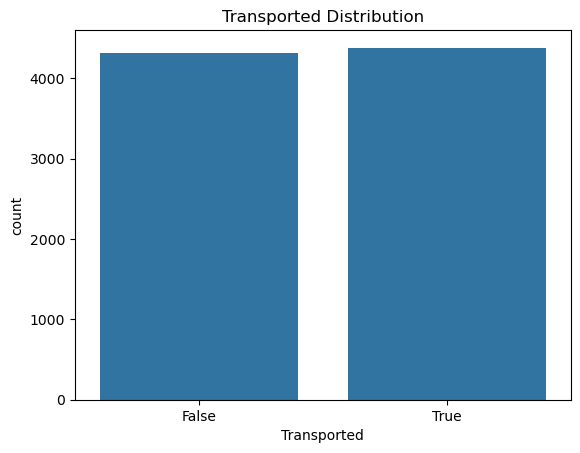

In [46]:
# ===== 셀 4: 정답(Transported) 분포 확인 =====
print(train['Transported'].value_counts())
sns.countplot(x='Transported', data=train)
plt.title('Transported Distribution')
plt.show()

# 셀 4-1: 숫자형 데이터 분포 시각화

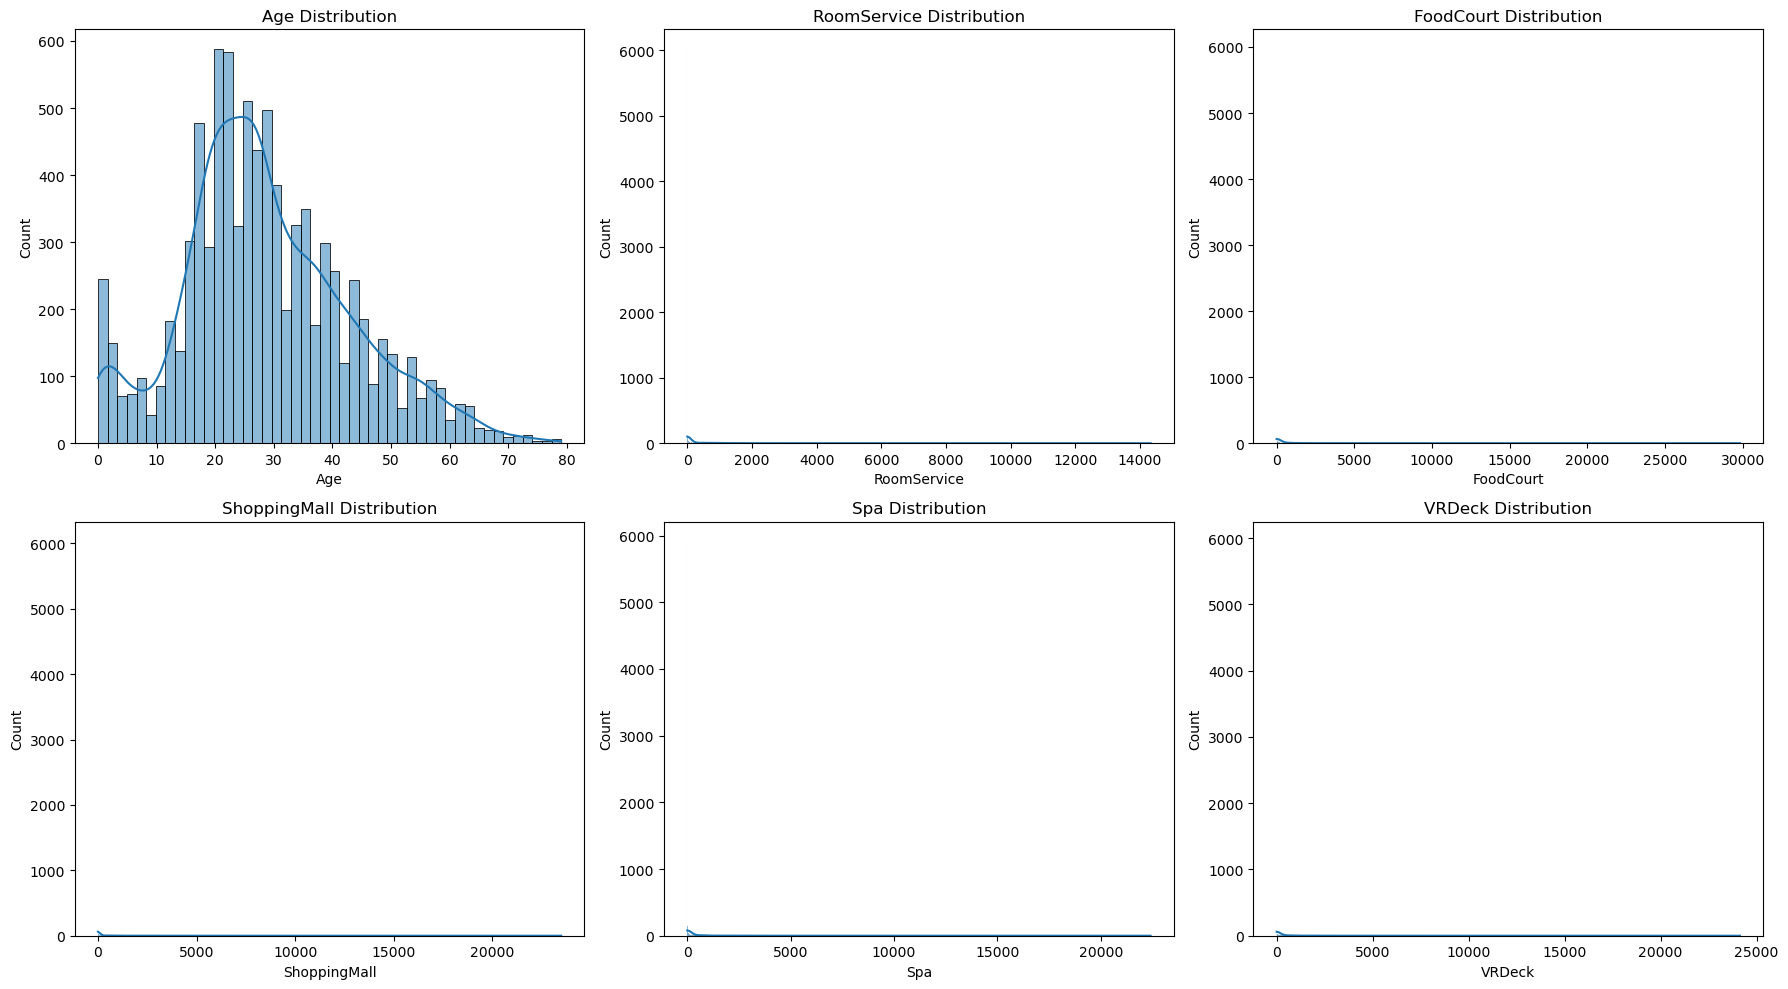

In [63]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    ax = axes[i//3][i%3]
    sns.histplot(train[col], kde=True, ax=ax)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

# 셀 4-2: 범주형 데이터 vs Transported 시각화

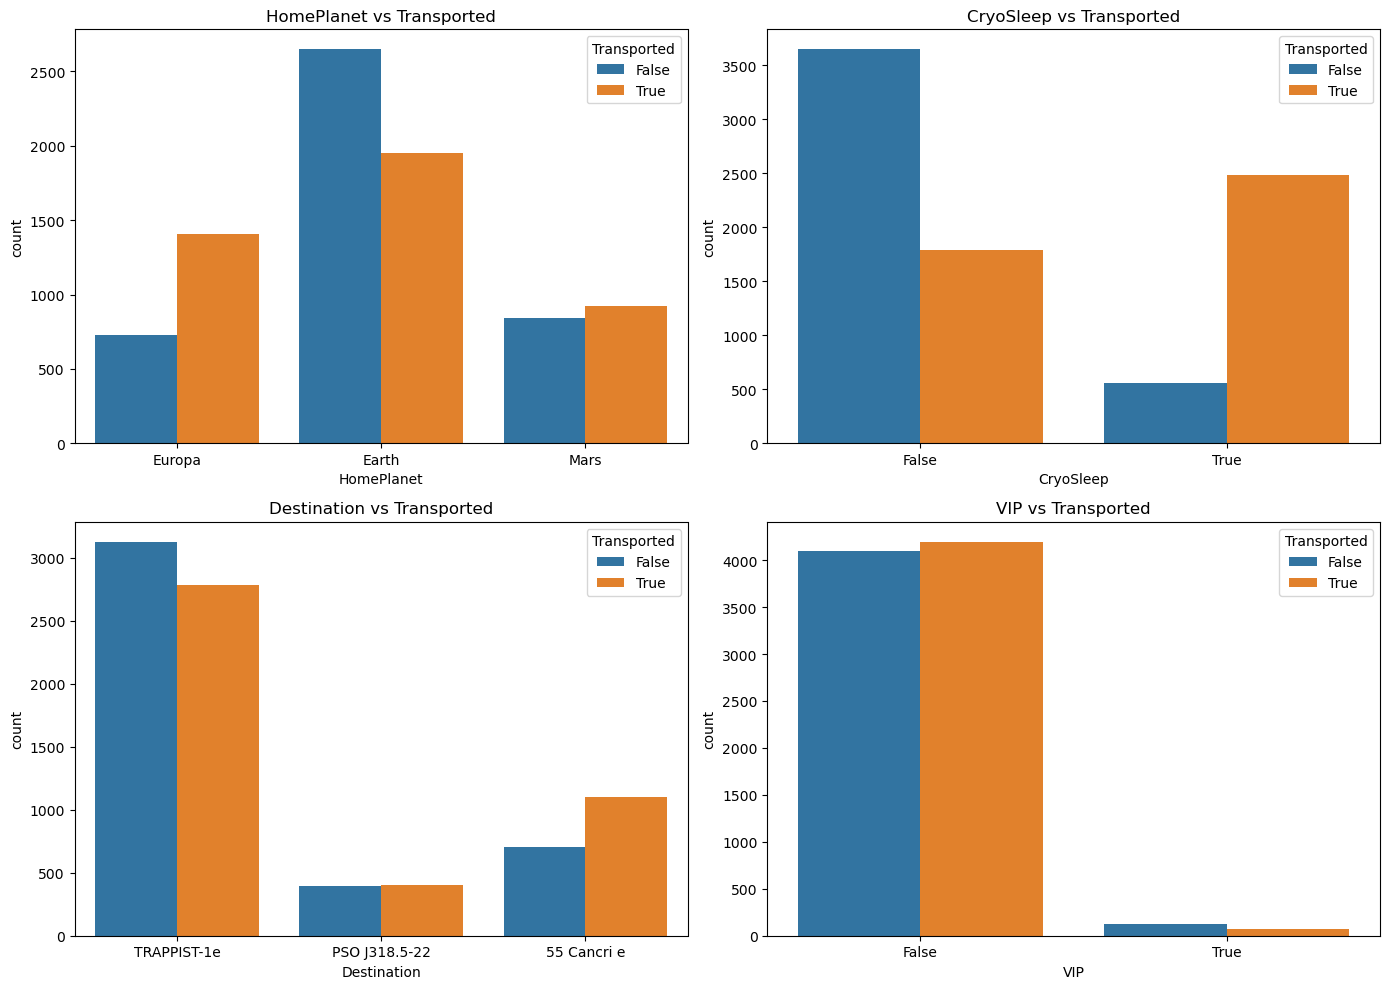

In [48]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cat_cols):
    ax = axes[i//2][i%2]
    sns.countplot(x=col, hue='Transported', data=train, ax=ax)
    ax.set_title(f'{col} vs Transported')

plt.tight_layout()
plt.show()

# 셀 4-3: 소비 금액 vs Transported 시각화 

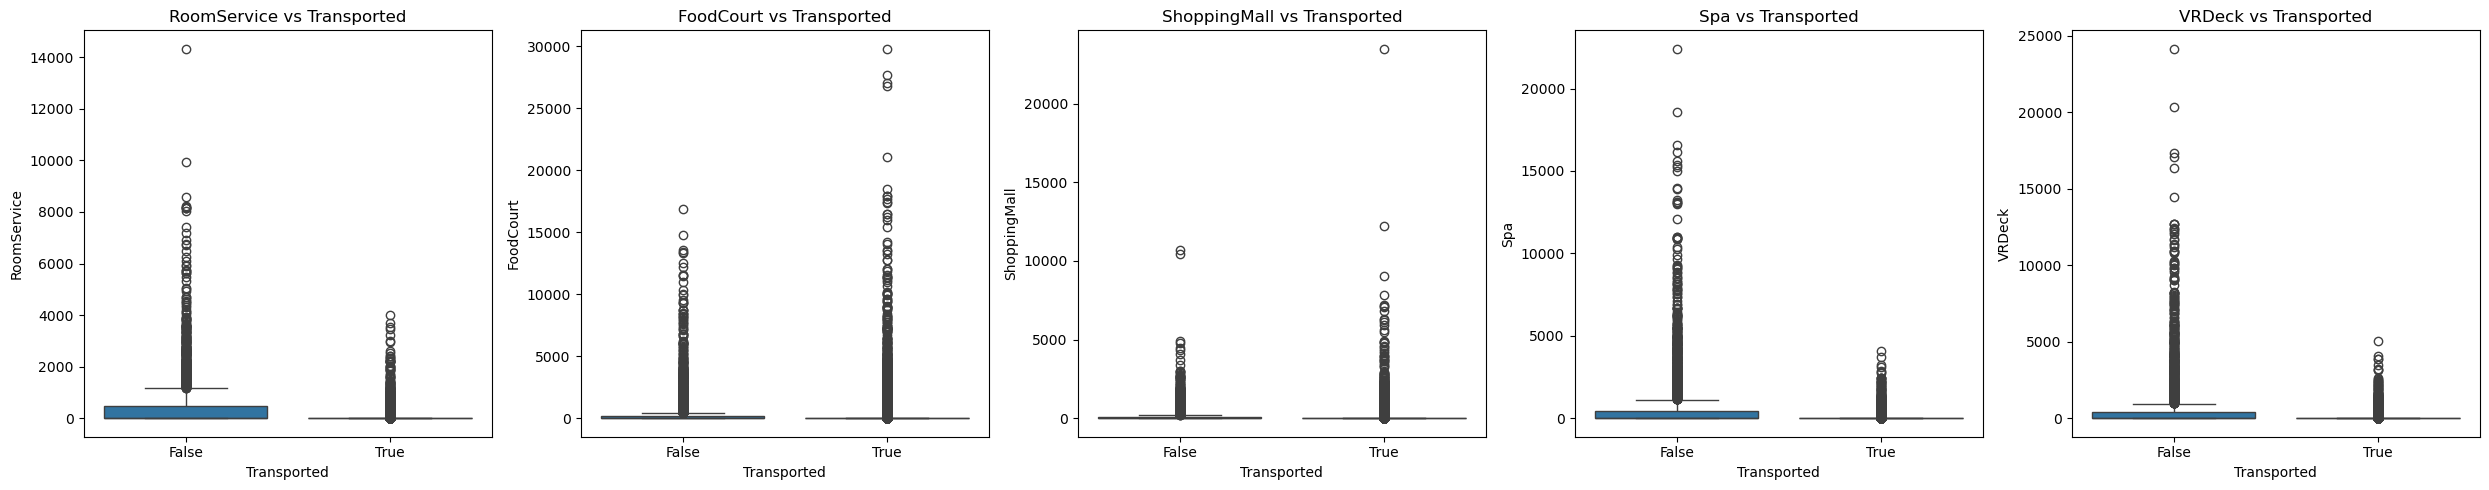

In [49]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(spend_cols):
    sns.boxplot(x='Transported', y=col, data=train, ax=axes[i])
    axes[i].set_title(f'{col} vs Transported')

plt.tight_layout()
plt.show()

# 셀 4-4: 상관관계 히트맵

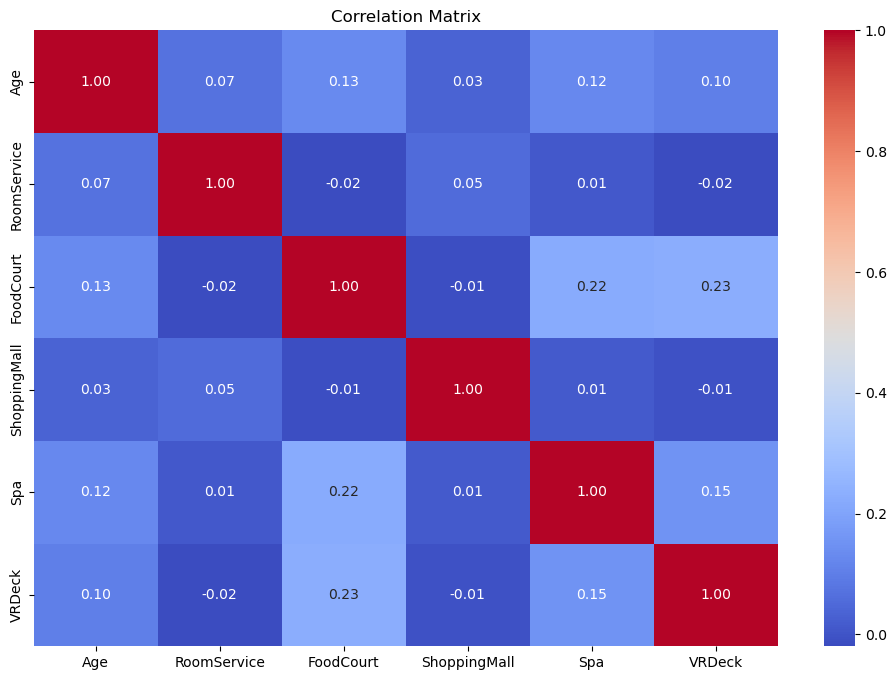

In [50]:
plt.figure(figsize=(12, 8))
numeric_data = train.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 셀 5: Cabin 컬럼 분해

In [51]:

# Cabin은 "Deck/Num/Side" 형태 (예: B/0/P)
# '/' 기준으로 나누기
train[['Deck', 'Cabin_num', 'Side']] = train['Cabin'].str.split('/', expand=True)
test[['Deck', 'Cabin_num', 'Side']] = test['Cabin'].str.split('/', expand=True)

# Cabin_num은 숫자로 변환
train['Cabin_num'] = pd.to_numeric(train['Cabin_num'], errors='coerce')
test['Cabin_num'] = pd.to_numeric(test['Cabin_num'], errors='coerce')

# 원래 Cabin 컬럼 삭제
train.drop(columns=['Cabin'], inplace=True)
test.drop(columns=['Cabin'], inplace=True)

print('Cabin 분해 완료!')
train[['Deck', 'Cabin_num', 'Side']].head()

Cabin 분해 완료!


,Deck,Cabin_num,Side
0,B,0.0,P
1,F,0.0,S
2,A,0.0,S
3,A,0.0,S
4,F,1.0,S


cabin(객실)분해 B/O/P 형태로 3가지 형태로 이동패턴 확인가능

# 셀 6: Name 제거 + PassengerId 분해

In [52]:

# 이름은 학습에 쓸모없음
train.drop(columns=['Name'], inplace=True)
test.drop(columns=['Name'], inplace=True)

# PassengerId = 그룹번호_개인번호 (예: 0001_01)
train[['Group', 'Group_num']] = train['PassengerId'].str.split('_', expand=True)
test[['Group', 'Group_num']] = test['PassengerId'].str.split('_', expand=True)

# 숫자로 변환
train['Group'] = train['Group'].astype(int)
test['Group'] = test['Group'].astype(int)

# PassengerId 삭제
train.drop(columns=['PassengerId'], inplace=True)
test.drop(columns=['PassengerId'], inplace=True)

print('Name 제거, PassengerId 분해 완료!')

Name 제거, PassengerId 분해 완료!


이름에서 사람성향파악 어려움,PassengerId가 "0001_01" 형태인데, 앞 번호는 그룹(가족/동행) 번호야. 같은 그룹이면 함께 이동했을 가능성이 높으니까 Group 정보를 살려두면 모델 성능에 도움이 됨. 단순 ID 자체는 의미 없으니 제거.

# 셀 7: 결측치 처리

In [53]:

# Age: 중앙값으로 채우기
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

# 범주형 데이터는 최빈값으로 채우기
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

# Cabin_num 결측치도 채우기
train['Cabin_num'].fillna(train['Cabin_num'].median(), inplace=True)
test['Cabin_num'].fillna(test['Cabin_num'].median(), inplace=True)

# 소비 관련 컬럼은 0으로 채우기 (쓴 돈 없다고 가정)
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train[col].fillna(0, inplace=True)
    test[col].fillna(0, inplace=True)

print('결측치 처리 완료!')
print('train 결측치:', train.isnull().sum().sum())
print('test 결측치:', test.isnull().sum().sum())

결측치 처리 완료!
train 결측치: 0
test 결측치: 0


소비기록 0은 데이터를 채울필요가 없음

# 셀 8: 새로운 Feature 생성 중요 중요 돈 돈

In [54]:
# 총 소비 금액
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train['TotalSpend'] = train[spend_cols].sum(axis=1)
test['TotalSpend'] = test[spend_cols].sum(axis=1)

# 소비 여부 (돈을 아예 안 쓴 사람)
train['No_spend'] = (train['TotalSpend'] == 0).astype(int)
test['No_spend'] = (test['TotalSpend'] == 0).astype(int)

print('Feature 생성 완료!')
print('TotalSpend 예시:')
print(train[['TotalSpend', 'No_spend']].head())

Feature 생성 완료!
TotalSpend 예시:
   TotalSpend  No_spend
0         0.0         1
1       736.0         0
2     10383.0         0
3      5176.0         0
4      1091.0         0


냉동인간은 돈을 안씀

# 셀 9: 인코딩 (문자 → 숫자)

In [55]:
# One-Hot Encoding
train = pd.get_dummies(train)
test = pd.get_dummies(test)

# train/test 컬럼 맞추기 (중요!!)
# train에는 있는데 test에는 없는 컬럼을 0으로 채워줌
train, test = train.align(test, join='left', axis=1, fill_value=0)

print('인코딩 완료!')
print('train 컬럼 수:', len(train.columns))

인코딩 완료!
train 컬럼 수: 37


모델은 숫자만 이해함 화성 지구 등을 숫자로 표현함

# 셀 10: X, y 분리

In [56]:
# align 때문에 test에 Transported가 생겼으니 제거
if 'Transported' in test.columns:
    test = test.drop(columns=['Transported'])

X = train.drop(columns=['Transported'])  # 입력 데이터
y = train['Transported'].astype(int)     # 정답 (True→1, False→0)

print('X:', X.shape)
print('y:', y.shape)
print('test:', test.shape)
print('NaN 확인 X:', X.isnull().sum().sum())
print('NaN 확인 y:', y.isnull().sum())

X: (8693, 36)
y: (8693,)
test: (4277, 36)
NaN 확인 X: 0
NaN 확인 y: 0


# 셀 11: 3가지 모델 준비

In [57]:
random_state = 42

models = [
    {'model': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, random_state=random_state), 
     'name': 'GradientBoosting'},
    {'model': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, 
        random_state=random_state, eval_metric='logloss'), 
     'name': 'XGBoost'},
    {'model': lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, 
        random_state=random_state, verbose=-1), 
     'name': 'LightGBM'},
]
print('모델 준비 완료!')

모델 준비 완료!


# 셀 12: 개별 모델 성능 확인

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

for m in models:
    m['model'].fit(X_train, y_train)
    y_pred = m['model'].predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{m['name']} 정확도: {acc:.4f}")

GradientBoosting 정확도: 0.8028
XGBoost 정확도: 0.8051
LightGBM 정확도: 0.8108


# 셀 13: 교차 검증

In [59]:
kfold = KFold(n_splits=5, shuffle=True, random_state=random_state)
for m in models:
    scores = cross_val_score(m['model'], X, y, cv=kfold, scoring='accuracy')
    print(f"{m['name']} CV 평균 정확도: {scores.mean():.4f}")

GradientBoosting CV 평균 정확도: 0.8102
XGBoost CV 평균 정확도: 0.8069
LightGBM CV 평균 정확도: 0.8089


# 셀 14: 전체 데이터로 학습 + 앙상블 예측

In [60]:
# 전체 train으로 다시 학습
for m in models:
    m['model'].fit(X, y)

# 각 모델의 예측 확률
pred1 = models[0]['model'].predict_proba(test)[:, 1]
pred2 = models[1]['model'].predict_proba(test)[:, 1]
pred3 = models[2]['model'].predict_proba(test)[:, 1]

# 3개 모델 평균 → 0.5 이상이면 True
pred_avg = (pred1 + pred2 + pred3) / 3
final_pred = (pred_avg >= 0.5)

print('예측 완료!')
print('True:', final_pred.sum())
print('False:', (~final_pred).sum())

예측 완료!
True: 2189
False: 2088


# 셀 15: 제출 파일 생성

In [61]:
sub = pd.read_csv(f'{data_dir}/sample_submission.csv')
sub['Transported'] = final_pred
sub.to_csv(f'{data_dir}/submission.csv', index=False)

print('제출 파일 생성 완료!')
print(sub.head(10))

제출 파일 생성 완료!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01        False
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01        False


# 셀 16: Feature 중요도 시각화

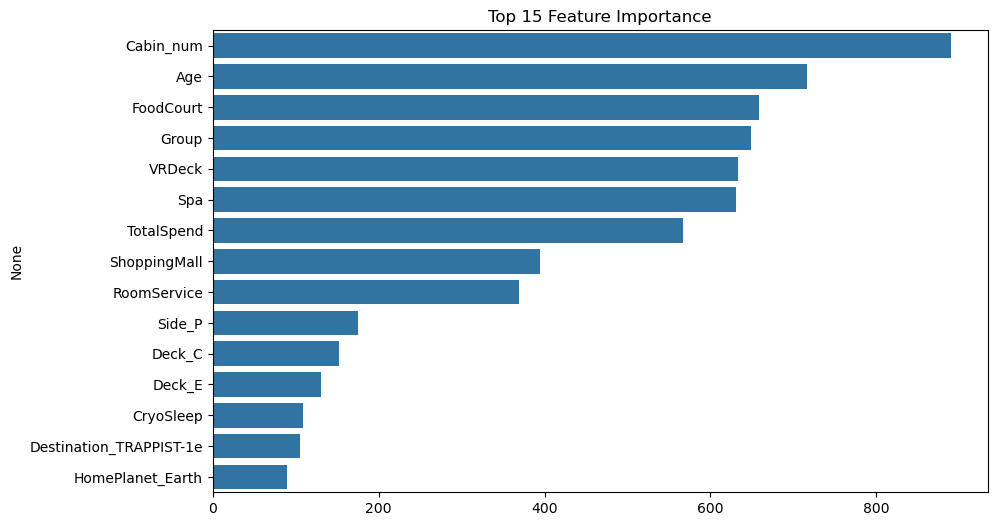

In [62]:
feature_imp = pd.Series(
    models[2]['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index)
plt.title('Top 15 Feature Importance')
plt.show()

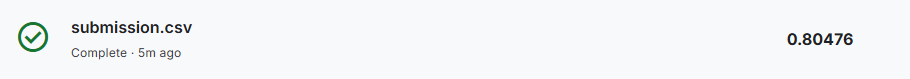

# 회고 (Retrospective)
- 캐글이나 블로그에서 나오는 내용을 참고하여 이와 비슷하게 하려고 노력했음
- 주피터를 사용할때마다 머신러닝 모델을 불러야해서 불편함
- ai가 전체적으로 짜주긴 하나 부족한점이 많음 중간마다 부족한 것을 넣어줘야함
- 주피터에 있는 마크다운에 대한 공부를 할 수 있었음
- Cabin 컬럼을 Deck/Num/Side로 분해하여 숨겨진 패턴을 추출한 점
- 시각화를 통해 CryoSleep과 소비 패턴의 관계를 발견하고, No_spend feature를 생성한 점
- GradientBoosting, XGBoost, LightGBM 3가지 모델을 앙상블하여 단일 모델보다 안정적인 예측을 시도한 점
- 회귀(주택 가격)와 분류(타이타닉)의 전체 흐름은 동일하다는 것을 체감했다. 데이터 불러오기 → 전처리 → 모델 학습 → 예측 → 제출.
- 시각화가 단순히 "보기 좋은 그래프"가 아니라 전처리 방향을 결정하는 근거가 된다는 것을 알게 되었다.
- 앙상블 기법으로 여러 모델의 예측을 평균내면 단일 모델보다 더 안정적인 결과를 낼 수 있다는 것을 경험했다.
- 다른 자료를 참고하여 어떤 과정을 수행할지를 정할수 있음
- 전반적으로 다 어려움... 입문3주차는 해결못함 ai도움이 절실함

# Reference

- [Kaggle - Spaceship Titanic Competition](https://www.kaggle.com/competitions/spaceship-titanic)
- [Scikit-learn 공식 문서 - GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
- [XGBoost 공식 문서](https://xgboost.readthedocs.io/)
- [LightGBM 공식 문서](https://lightgbm.readthedocs.io/)
- [Pandas 공식 문서 - get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)
- [Seaborn 공식 문서 - 시각화](https://seaborn.pydata.org/)